In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../data/deliveries.csv")
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
df.shape

(260920, 17)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

In [23]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [8]:
df["match_id"].is_unique

False

In [11]:
df.duplicated(subset=["match_id", "inning"]).sum()

np.int64(258703)

In [21]:
df.duplicated(subset=["match_id", "inning", "over", "ball"]).sum()

np.int64(0)

In [13]:
balls_per_match = df.groupby('match_id').size()
max_balls = balls_per_match.max()
max_balls

np.int64(269)

In [16]:
excess_balls_matches = balls_per_match[balls_per_match > 240]
excess_balls_matches.count()

np.int64(707)

In [17]:
dismissal_types = df['dismissal_kind'].value_counts()
dismissal_types

dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64

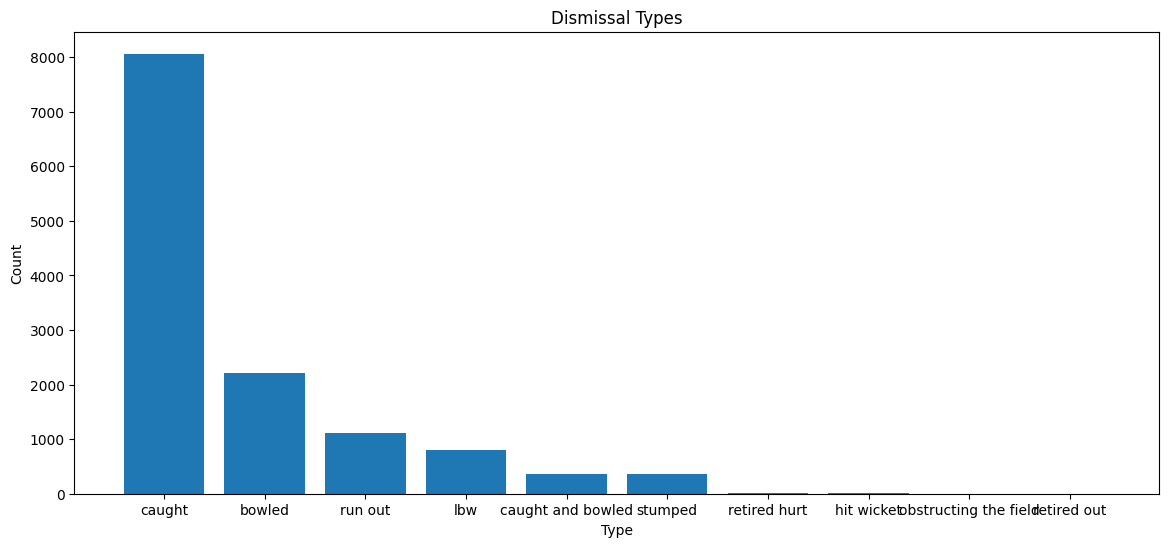

In [20]:
plt.figure(figsize=(14, 6)) 
plt.bar(dismissal_types.index, dismissal_types.values)
plt.title('Dismissal Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()